In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nih-chest-xrays/data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/nih-chest-xrays/data


# Imports

In [27]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


# Load metadata and connect images

In [29]:
BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = os.path.join(BASE_PATH, "Data_Entry_2017.csv")

image_paths = {}
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths[file] = os.path.join(root, file)

print("Total images found:", len(image_paths))

df = pd.read_csv(CSV_PATH)
print("Metadata shape:", df.shape)
df.head()


Total images found: 112120
Metadata shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [30]:
df = df.copy()

if "View Position" in df.columns:
    df = df[df["View Position"].isin(["PA", "AP"])].copy()

df = df[
    (df["Finding Labels"] == "No Finding") |
    (df["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

df["label"] = df["Finding Labels"].apply(lambda x: 1 if "Pneumonia" in x else 0)
df["path"] = df["Image Index"].map(image_paths)

keep_cols = ["Image Index", "Finding Labels", "label", "path"]
if "Patient ID" in df.columns:
    keep_cols.append("Patient ID")
if "View Position" in df.columns:
    keep_cols.append("View Position")

df = df[keep_cols].dropna(subset=["path"]).drop_duplicates().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()


Filtered dataset shape: (61792, 6)
label
0    60361
1     1431
Name: count, dtype: int64


,Image Index,Finding Labels,label,path,Patient ID,View Position
0,00000002_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,2,PA
1,00000005_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA
2,00000005_001.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
3,00000005_002.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
4,00000005_003.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA


In [31]:
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                  60361
Pneumonia                                                     322
Infiltration|Pneumonia                                        199
Edema|Infiltration|Pneumonia                                  137
Atelectasis|Pneumonia                                         108
                                                            ...  
Mass|Nodule|Pneumonia|Pneumothorax                              1
Atelectasis|Effusion|Infiltration|Pneumonia|Pneumothorax        1
Cardiomegaly|Consolidation|Effusion|Pneumonia                   1
Consolidation|Nodule|Pneumonia                                  1
Consolidation|Pneumonia|Mass                                    1
Name: count, Length: 143, dtype: int64

In [32]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique patients:", df["Patient ID"].nunique() if "Patient ID" in df.columns else "Patient ID not found")
print("Unique images:", df["Image Index"].nunique())
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))


Missing values per column:
Image Index       0
Finding Labels    0
label             0
path              0
Patient ID        0
View Position     0
dtype: int64

Unique patients: 25052
Unique images: 61792

Class distribution:
label
0    0.976842
1    0.023158
Name: ratio, dtype: float64


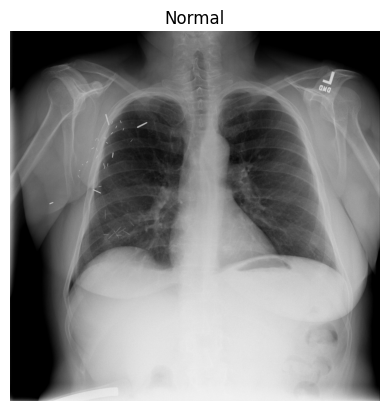

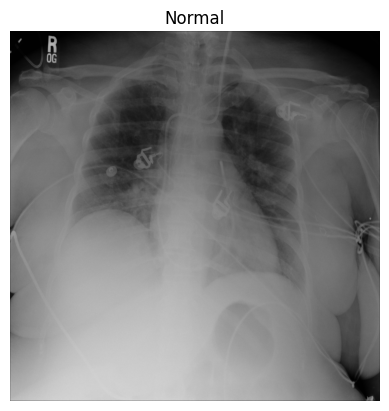

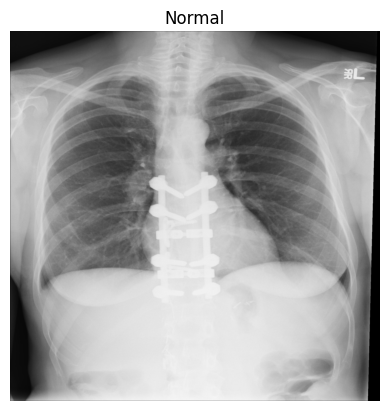

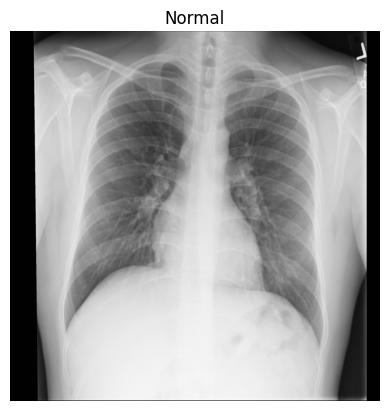

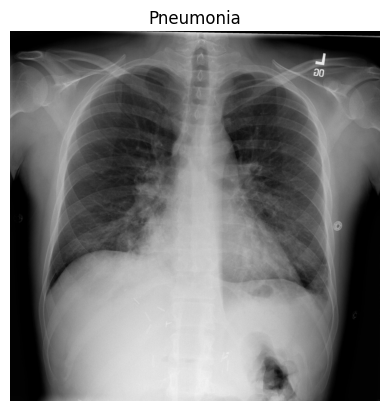

In [33]:
import cv2
import matplotlib.pyplot as plt

sample = df.sample(5)

for _, row in sample.iterrows():
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")
    plt.show()

# Data preprocessing

In [34]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

if "Patient ID" in df.columns:
    patient_level = df.groupby("Patient ID")["label"].max().value_counts()
    print("\nPatient-level label distribution:")
    print(patient_level)

print("\nImage-level label distribution:")
print(df["label"].value_counts())


Duplicates before: 0
Duplicates after: 0

Patient-level label distribution:
label
0    24044
1     1008
Name: count, dtype: int64

Image-level label distribution:
label
0    60361
1     1431
Name: count, dtype: int64


# Class imbalance strategy

label
0    60361
1     1431
Name: count, dtype: int64
(61792, 6)


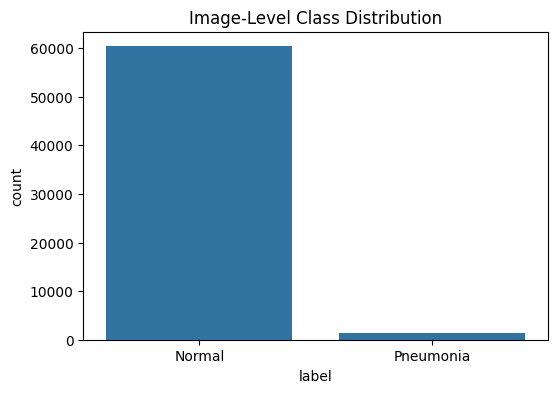

In [35]:
df_model = df.copy().reset_index(drop=True)

print(df_model["label"].value_counts())
print(df_model.shape)

plt.figure(figsize=(6, 4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Image-Level Class Distribution")
plt.show()


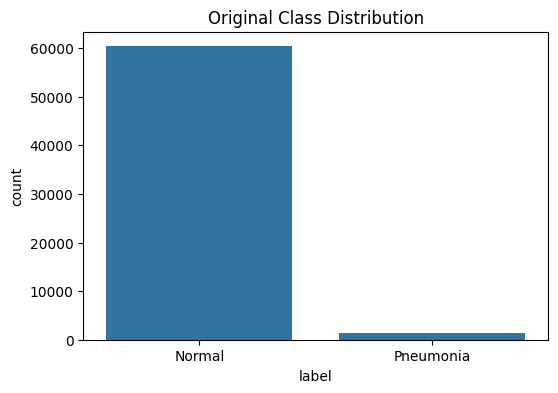

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Original Class Distribution")
plt.show()


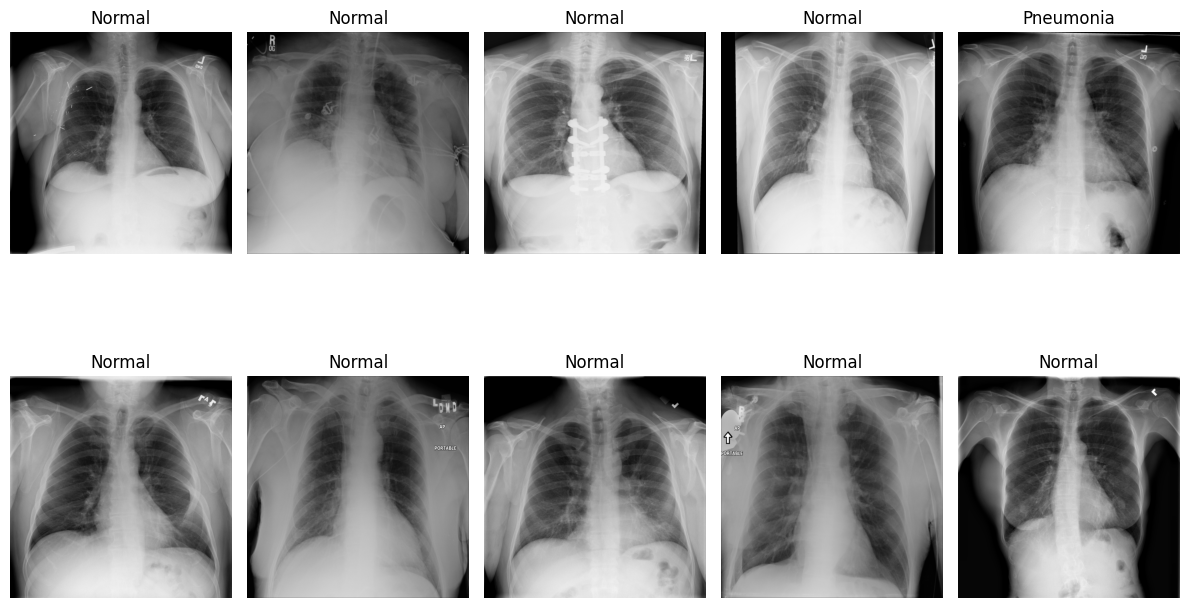

In [37]:
fig, axes = plt.subplots(2, 5, figsize=(12, 8))
samples = df_model.sample(10, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img = cv2.imread(samples.loc[i, "path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Pneumonia" if samples.loc[i, "label"] == 1 else "Normal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [38]:
sizes = []

for p in df_model["path"].sample(min(200, len(df_model)), random_state=42):
    img = cv2.imread(p)
    if img is not None:
        sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])
sizes_df.describe()


,Height,Width
count,200.0,200.0
mean,1024.0,1024.0
std,0.0,0.0
min,1024.0,1024.0
25%,1024.0,1024.0
50%,1024.0,1024.0
75%,1024.0,1024.0
max,1024.0,1024.0


In [39]:
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

class_weights = {0: 1.0, 1: 2.0}

In [40]:
assert "Patient ID" in df_model.columns, "Patient ID column is required for patient-level split."

patient_labels = df_model.groupby("Patient ID")["label"].max().reset_index()

train_pat, temp_pat = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["label"],
    random_state=SEED
)

train_df = df_model[df_model["Patient ID"].isin(train_pat["Patient ID"])].copy()
val_df   = df_model[df_model["Patient ID"].isin(val_pat["Patient ID"])].copy()
test_df  = df_model[df_model["Patient ID"].isin(test_pat["Patient ID"])].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())
print("\nTest label counts:")
print(test_df["label"].value_counts())

assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
print("\nNo patient leakage detected.")


Train: (43018, 6)
Validation: (9271, 6)
Test: (9503, 6)

Train label counts:
label
0    42043
1      975
Name: count, dtype: int64

Validation label counts:
label
0    9070
1     201
Name: count, dtype: int64

Test label counts:
label
0    9248
1     255
Name: count, dtype: int64

No patient leakage detected.


In [41]:
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print(class_weights)


{0: 0.5115952715077421, 1: 22.06051282051282}


In [42]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
    tf.keras.layers.RandomZoom(0.05, 0.05),
], name="train_augmentation")

def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

def prepare_train(path, label):
    image, label = decode_image(path, label)
    image = train_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

def prepare_eval(path, label):
    image, label = decode_image(path, label)
    image = preprocess_input(image)
    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["path"].values,
        dataframe["label"].values.astype("float32")
    ))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(prepare_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(prepare_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [43]:
tf.keras.backend.clear_session()

In [44]:
train_gen = make_dataset(train_df, training=True)
val_gen = make_dataset(val_df, training=False)
test_gen = make_dataset(test_df, training=False)

for images, labels in train_gen.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Batch label distribution:", np.unique(labels.numpy(), return_counts=True))


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Batch label distribution: (array([0., 1.], dtype=float32), array([30,  2]))


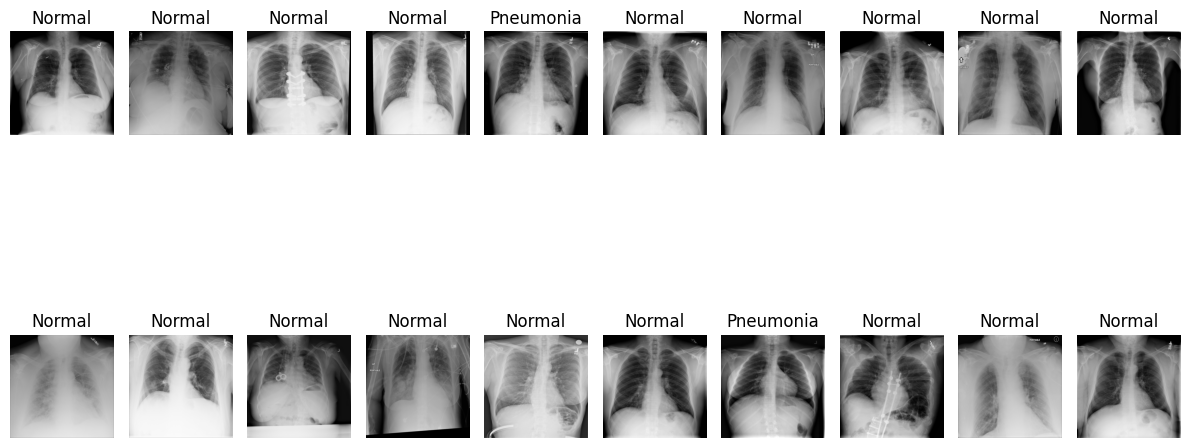

In [45]:
import matplotlib.pyplot as plt
import cv2

samples = df_model.sample(20, random_state=42)

plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 10, i + 1)
    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Mohamed Hatem's Model

In [46]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet_v2 import preprocess_input

# 1. Load the base ResNet50V2 model without the top classification layer
base_model = ResNet50V2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base model for the first phase of training
base_model.trainable = False

# 2. Build the custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Heavy dropout to prevent overfitting on the minority class
outputs = Dense(1, activation='sigmoid')(x) # Single node for Binary Classification

# 3. Assemble the final model
model = Model(inputs=base_model.input, outputs=outputs)

# 4. Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0), # Using your focal loss!
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

Starting model training...
Epoch 1/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.5608 - auc: 0.5612 - loss: 9.7521 - precision: 0.0290 - recall: 0.5491
Epoch 1: val_auc improved from -inf to 0.59052, saving model to best_resnet50v2_pneumonia.keras
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 599s 445ms/step - accuracy: 0.5608 - auc: 0.5612 - loss: 9.7521 - precision: 0.0290 - recall: 0.5491 - val_accuracy: 0.9488 - val_auc: 0.5905 - val_loss: 0.4567 - val_precision: 0.0772 - val_recall: 0.1244 - learning_rate: 0.0010
Epoch 2/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5619 - auc: 0.5735 - loss: 9.3987 - precision: 0.0289 - recall: 0.5509
Epoch 2: val_auc improved from 0.59052 to 0.63893, saving model to best_resnet50v2_pneumonia.keras
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 549s 408ms/step - accuracy: 0.5619 - auc: 0.5735 - loss: 9.3989 - precision: 0.0289 - recall: 0.5509 - val_accuracy: 0.2309 - val_auc: 0.6389 - val_loss: 7.8593 - val_precision: 0.0257 - val_recall: 0.9353 

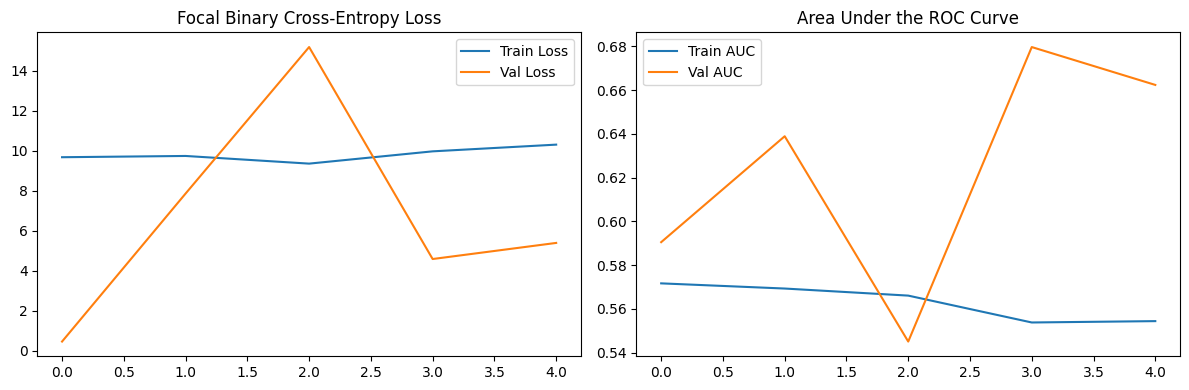

In [50]:
# Define the number of epochs (20 is a safe starting point for a frozen base model)
EPOCHS = 5

# 1. Set up Callbacks
callbacks = [
    # Save the model only when Validation AUC hits a new high
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_resnet50v2_pneumonia.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    # Stop training if Validation AUC doesn't improve for 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    # Drop the learning rate if the model gets stuck on a plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        mode="max",
        verbose=1
    )
]

# 2. Execute the Training
print("Starting model training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights, # Passing the dictionary you calculated earlier
    callbacks=callbacks
)

# 3. Evaluate on the Unseen Test Set
print("\n--- Training Complete ---")
print("Evaluating on Test Set...")

# The EarlyStopping callback already restores the best weights, 
# but loading explicitly is a good safety habit.
model.load_weights("best_resnet50v2_pneumonia.keras") 

test_results = model.evaluate(test_gen, return_dict=True)

print("\n--- Final Test Results ---")
print(f"Test AUC:       {test_results['auc']:.4f}")
print(f"Test Accuracy:  {test_results['accuracy']:.4f}")
print(f"Test Precision: {test_results['precision']:.4f}")
print(f"Test Recall:    {test_results['recall']:.4f}")

# Optional: Plot the training history to visualize learning
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Focal Binary Cross-Entropy Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Area Under the ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

Generating predictions...
297/297 ━━━━━━━━━━━━━━━━━━━━ 51s 162ms/step


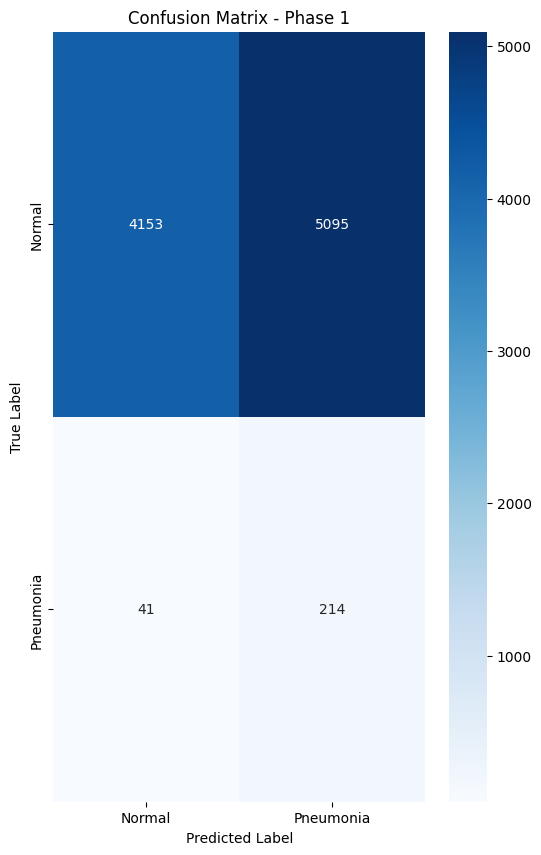


Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.45      0.62      9248
   Pneumonia       0.04      0.84      0.08       255

    accuracy                           0.46      9503
   macro avg       0.52      0.64      0.35      9503
weighted avg       0.96      0.46      0.60      9503



In [51]:
# 1. Generate predictions on the test set
print("Generating predictions...")
y_pred_probs = model.predict(test_gen)
# Threshold at 0.5 (we can tune this later based on the Precision-Recall curve)
y_pred_classes = (y_pred_probs > 0.5).astype(int) 

# 2. Extract the true labels directly from the test generator
y_true = np.concatenate([y for x, y in test_gen], axis=0)

# 3. Plot the Confusion Matrix
plt.figure(figsize=(6, 10))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix - Phase 1')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Print the detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['Normal', 'Pneumonia']))

In [52]:
# 1. Unfreeze the entire base model
base_model.trainable = True

# 2. Re-compile the model. 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Starting = Fine-Tuning...")

# 3. Train for another 5 epochs
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights, 
    callbacks=callbacks
)

Starting = Fine-Tuning...
Epoch 1/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.8280 - auc: 0.5476 - loss: 8.7060 - precision: 0.0286 - recall: 0.2554
Epoch 1: val_auc improved from 0.67970 to 0.68828, saving model to best_resnet50v2_pneumonia.keras
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 833s 582ms/step - accuracy: 0.8279 - auc: 0.5476 - loss: 8.7017 - precision: 0.0286 - recall: 0.2555 - val_accuracy: 0.5320 - val_auc: 0.6883 - val_loss: 0.2033 - val_precision: 0.0327 - val_recall: 0.7214 - learning_rate: 1.0000e-05
Epoch 2/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.5574 - auc: 0.6485 - loss: 0.1924 - precision: 0.0336 - recall: 0.6878
Epoch 2: val_auc improved from 0.68828 to 0.72016, saving model to best_resnet50v2_pneumonia.keras
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 760s 565ms/step - accuracy: 0.5574 - auc: 0.6485 - loss: 0.1924 - precision: 0.0336 - recall: 0.6878 - val_accuracy: 0.5946 - val_auc: 0.7202 - val_loss: 0.1687 - val_precision: 0.0384 - val_recall: 0

In [55]:
import matplotlib.cm as cm

# 1. Find the last convolutional layer dynamically
# This saves us from guessing if ResNet50V2 named it 'post_relu' or 'conv5_block3_out'
last_conv_layer_name = None

for layer in reversed(model.layers):
    try:
        # Look directly at the output tensor's shape instead of the layer attribute
        if len(layer.output.shape) == 4: 
            last_conv_layer_name = layer.name
            break
    except AttributeError:
        # If a layer (like Dense) doesn't have a standard output shape accessible this way, skip it
        pass
        
print(f"Targeting layer for Grad-CAM: {last_conv_layer_name}")
print(f"Targeting layer for Grad-CAM: {last_conv_layer_name}")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a sub-model that outputs both the last conv layer activations and the final prediction
    grad_model = tf.keras.models.Model(
        model.inputs, 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        
        # For binary classification, we care about the single output neuron
        # If pred_index is None, we just take the highest prediction
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calculate gradients of the predicted class wrt the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pool the gradients over the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature map by the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to the heatmap (we only care about features that *positively* influence the class)
    # and normalize it to be between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Get RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # Display
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original X-Ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")
    plt.show()

Targeting layer for Grad-CAM: post_relu
Targeting layer for Grad-CAM: post_relu


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Model Prediction Confidence for Pneumonia: 0.5308


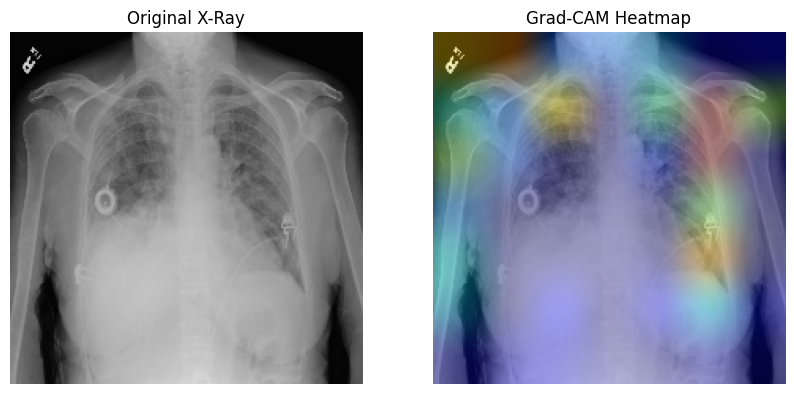

In [58]:
# Grab a sample path from your test dataframe where the true label is Pneumonia (1)
sample_pneumonia_path = test_df[test_df['label'] == 1]['path'].iloc[5]

# Preprocess the image exactly how your model expects it
img_array, _ = prepare_eval(sample_pneumonia_path, 1)
img_array = tf.expand_dims(img_array, axis=0)

# Get the model's prediction
prediction = model.predict(img_array)[0][0]
print(f"Model Prediction Confidence for Pneumonia: {prediction:.4f}")

# Generate and display the heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
display_gradcam(sample_pneumonia_path, heatmap)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Model Prediction Confidence for Pneumonia: 0.5254


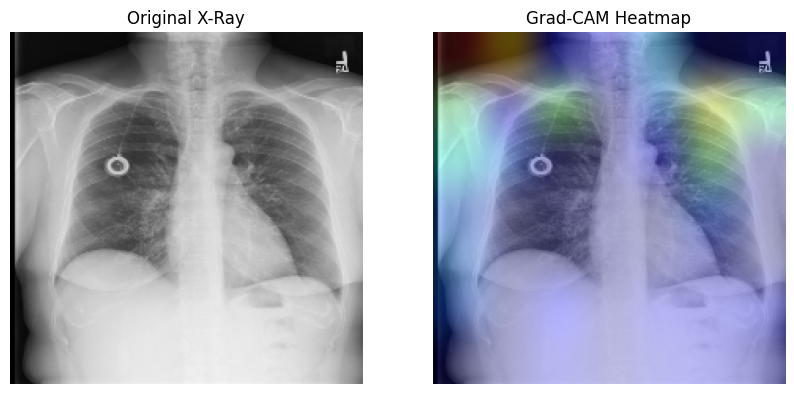

In [59]:
# Grab a sample path from your test dataframe where the true label is Pneumonia (1)
sample_pneumonia_path = test_df[test_df['label'] == 1]['path'].iloc[4]

# Preprocess the image exactly how your model expects it
img_array, _ = prepare_eval(sample_pneumonia_path, 1)
img_array = tf.expand_dims(img_array, axis=0)

# Get the model's prediction
prediction = model.predict(img_array)[0][0]
print(f"Model Prediction Confidence for Pneumonia: {prediction:.4f}")

# Generate and display the heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
display_gradcam(sample_pneumonia_path, heatmap)